### LIBRARY IMPORTS

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import copy
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

if os.getcwd().endswith('notebooks'):
    os.chdir('..')

from src import *
from src.data_manager import DataManager
from src.processor import Processor
from src.nn_regressor import NNRegressor
from src.gb_regressor import GBRegressor

### CONFIGURATION

In [2]:
data_manager = DataManager()

datasets_config, modeling_config = data_manager.load_config()

active_dataset = modeling_config["main"]["active_dataset"]
active_dataset_config = datasets_config[active_dataset]
target = active_dataset_config["target"]

problem_type = active_dataset_config["problem_type"]

gradient_boosting_config = modeling_config["gradient_boosting"]

weak_learner_key = gradient_boosting_config["weak_learner_key"]
weak_learner_config = modeling_config[weak_learner_key]

processor = Processor(**active_dataset_config)

raw_train, raw_test = data_manager.load_raw_data()
raw_train = processor.cut_data(raw_train)

### CROSS-VALIDATION

In [3]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def my_cross_validation(model, data, target, kf, processor):
    mse_scores = []
    r2_scores = []
    oof_preds = np.zeros(len(data))

    for train_idx, valid_idx in kf.split(data):
        train_df = raw_train.iloc[train_idx]
        valid_df = raw_train.iloc[valid_idx]

        train_proc = processor.fit_transform(train_df)
        valid_proc = processor.transform(valid_df)

        X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
        X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

        model.fit(X_train, y_train)

        preds = model.predict(X_valid)
        oof_preds[valid_idx] = preds

        fold_mse = mean_squared_error(y_valid, preds)
        fold_r2 = r2_score(y_valid, preds)
        
        mse_scores.append(fold_mse)
        r2_scores.append(fold_r2)
    
    return mse_scores, r2_scores, oof_preds

### RIDGE REGRESSION

In [4]:
%%time

ridge = Ridge(alpha=1.0, random_state=42)
ridge_mse_scores, ridge_r2_scores, ridge_oof_preds = my_cross_validation(ridge, raw_train, target, kf, processor)

CPU times: total: 1.08 s
Wall time: 1.08 s


In [5]:
print("Ridge MSE scores:", ridge_mse_scores)
print("Ridge R2 scores:", ridge_r2_scores)

Ridge MSE scores: [0.01206151807514626, 0.012292627662309843, 0.012080486735903177, 0.01227748025803125, 0.012255805037537999]
Ridge R2 scores: [0.7801613291103521, 0.7780645197870598, 0.7791724013834471, 0.7769449852617083, 0.7756258485946159]


### DECISION TREE

In [6]:
%%time

dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_mse_scores, dt_r2_scores, dt_oof_preds = my_cross_validation(dt, raw_train, target, kf, processor)

CPU times: total: 1.72 s
Wall time: 1.71 s


In [7]:
print("Decision tree MSE scores:", dt_mse_scores)
print("Decision tree R2 scores:", dt_r2_scores)

Decision tree MSE scores: [0.017833131175414893, 0.018043508431977214, 0.01791111399581419, 0.018086290485257433, 0.01804981931225231]
Decision tree R2 scores: [0.6749653044518265, 0.6742360690826752, 0.6725903203479433, 0.6714115839761872, 0.6695514591817715]


### RANDOM FOREST

In [8]:
%%time

rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_mse_scores, rf_r2_scores, rf_oof_preds = my_cross_validation(rf, raw_train, target, kf, processor)

CPU times: total: 48.4 s
Wall time: 48.5 s


In [9]:
print("Random forest MSE scores:", rf_mse_scores)
print("Random forest R2 scores:", rf_r2_scores)

Random forest MSE scores: [0.01667669954798179, 0.016918746225209624, 0.0168425641186361, 0.016951252744353558, 0.01689960982579473]
Random forest R2 scores: [0.6960429491036638, 0.6945429267653251, 0.6921230849242217, 0.6920327419585197, 0.6906090132691516]


### NEURAL NETWORK

In [10]:
class MLP(NNRegressor):
    def __init__(self, **hyperparameters):
        super().__init__(**hyperparameters)

    def fit(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_valid: np.ndarray,
        y_valid: np.ndarray, 
        patience: int = 10
    ) -> None:
        
        input_size = X_train.shape[1]
        output_size = y_train.shape[1] if len(y_train.shape) > 1 else 1
        self._get_network(input_size, output_size)
        
        train_loader = self._prepare_loader(X_train, y_train)
        
        X_valid_t = torch.from_numpy(X_valid).to(torch.float32).to(self.device)
        y_valid_t = torch.from_numpy(y_valid).to(torch.float32).view(-1, output_size).to(self.device)

        criterion = nn.MSELoss()
        optimizer = optim.Adam(self.parameters(), self.learning_rate)
        
        best_loss = float('inf')
        best_model = None
        early_stop_count = 0

        for epoch in range(self.epochs):
            self.train()
            train_loss = 0
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)
                
                optimizer.zero_grad()
                preds = self(batch_X)
                loss = criterion(preds, batch_y.view_as(preds))
                loss.backward()
                optimizer.step()
                train_loss += loss.item()

            self.eval()
            with torch.no_grad():
                val_preds = self(X_valid_t)
                val_loss = criterion(val_preds, y_valid_t).item()

                val_preds_np = val_preds.cpu().numpy().flatten()
                y_valid_np = y_valid_t.cpu().numpy().flatten()
                val_r2 = r2_score(y_valid_np, val_preds_np)

            if (epoch+1) % 1 == 0:
                print(f"Epoch: {epoch+1} | Validation MSE: {val_loss:.4f} | R^2: {val_r2:.4f}")

            if val_loss < best_loss:
                best_loss = val_loss
                best_model = copy.deepcopy(self.state_dict())
                early_stop_count = 0
            else:
                early_stop_count += 1

            if early_stop_count >= patience:
                print("-"*50)
                break
                
        if best_model:
            self.load_state_dict(best_model)

In [11]:
%%time

mlp = MLP(epochs=100, learning_rate=0.001, hidden_size=[16, 8], batch_size=1024)

mlp_mse_scores = []
mlp_r2_scores = []
mlp_oof_preds = np.zeros(len(raw_train))

for train_idx, valid_idx in kf.split(raw_train):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    mlp.fit(X_train.values, y_train.values, X_valid.values, y_valid.values)

    preds = mlp.predict(X_valid.values).ravel()
    mlp_oof_preds[valid_idx] = preds

    fold_mse = mean_squared_error(y_valid, preds)
    fold_r2 = r2_score(y_valid, preds)
    
    mlp_mse_scores.append(fold_mse)
    mlp_r2_scores.append(fold_r2)

Epoch: 1 | Validation MSE: 0.0525 | R^2: 0.0425
Epoch: 2 | Validation MSE: 0.0367 | R^2: 0.3310
Epoch: 3 | Validation MSE: 0.0181 | R^2: 0.6709
Epoch: 4 | Validation MSE: 0.0122 | R^2: 0.7777
Epoch: 5 | Validation MSE: 0.0122 | R^2: 0.7770
Epoch: 6 | Validation MSE: 0.0121 | R^2: 0.7793
Epoch: 7 | Validation MSE: 0.0121 | R^2: 0.7788
Epoch: 8 | Validation MSE: 0.0121 | R^2: 0.7791
Epoch: 9 | Validation MSE: 0.0121 | R^2: 0.7796
Epoch: 10 | Validation MSE: 0.0121 | R^2: 0.7797
Epoch: 11 | Validation MSE: 0.0121 | R^2: 0.7794
Epoch: 12 | Validation MSE: 0.0121 | R^2: 0.7797
Epoch: 13 | Validation MSE: 0.0121 | R^2: 0.7797
Epoch: 14 | Validation MSE: 0.0121 | R^2: 0.7797
Epoch: 15 | Validation MSE: 0.0121 | R^2: 0.7797
Epoch: 16 | Validation MSE: 0.0121 | R^2: 0.7796
Epoch: 17 | Validation MSE: 0.0121 | R^2: 0.7790
Epoch: 18 | Validation MSE: 0.0122 | R^2: 0.7775
Epoch: 19 | Validation MSE: 0.0121 | R^2: 0.7796
Epoch: 20 | Validation MSE: 0.0121 | R^2: 0.7791
-----------------------------

In [12]:
print("Neural network MSE scores:", mlp_mse_scores)
print("Neural network R2 scores:", mlp_r2_scores)

Neural network MSE scores: [0.01208437762781041, 0.012306376574940407, 0.012086597887879197, 0.012283879053412198, 0.012256128479468765]
Neural network R2 scores: [0.7797446805887058, 0.7778162920190923, 0.7790606913964948, 0.7768287331181082, 0.7756199271550595]


### GRADIENT BOOSTING (DTs)

In [13]:
%%time

gb_mse_scores = []
gb_r2_scores = []
gb_oof_preds = np.zeros(len(raw_train))

for train_idx, valid_idx in kf.split(raw_train):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    gb = GBRegressor(
        n_estimators=1000,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        early_stopping_rounds=10,
        weak_learner_key="decision_tree",
        weak_learner_config={"max_depth": 5, "random_state": 42}
    )
    
    gb.fit(X_train.values, y_train.values, X_valid.values, y_valid.values)

    preds = gb.predict(X_valid.values).ravel()
    gb_oof_preds[valid_idx] = preds

    fold_mse = mean_squared_error(y_valid, preds)
    fold_r2 = r2_score(y_valid, preds)
    
    gb_mse_scores.append(fold_mse)
    gb_r2_scores.append(fold_r2)
    
    print('-' * 50)

2026-04-24 14:43:22,916 - INFO - Iteration: 10 | Validation MSE: 0.027377 | Validation R^2: 0.501020 
2026-04-24 14:43:24,197 - INFO - Iteration: 20 | Validation MSE: 0.018022 | Validation R^2: 0.671530 
2026-04-24 14:43:25,502 - INFO - Iteration: 30 | Validation MSE: 0.014567 | Validation R^2: 0.734500 
2026-04-24 14:43:26,828 - INFO - Iteration: 40 | Validation MSE: 0.013193 | Validation R^2: 0.759534 
2026-04-24 14:43:28,078 - INFO - Iteration: 50 | Validation MSE: 0.012544 | Validation R^2: 0.771362 
2026-04-24 14:43:29,357 - INFO - Iteration: 60 | Validation MSE: 0.012224 | Validation R^2: 0.777207 
2026-04-24 14:43:30,637 - INFO - Iteration: 70 | Validation MSE: 0.012072 | Validation R^2: 0.779969 
2026-04-24 14:43:31,869 - INFO - Iteration: 80 | Validation MSE: 0.011991 | Validation R^2: 0.781446 
2026-04-24 14:43:33,085 - INFO - Iteration: 90 | Validation MSE: 0.011950 | Validation R^2: 0.782192 
2026-04-24 14:43:34,286 - INFO - Iteration: 100 | Validation MSE: 0.011928 | Valid

--------------------------------------------------


2026-04-24 14:43:43,920 - INFO - Iteration: 10 | Validation MSE: 0.027309 | Validation R^2: 0.506955 
2026-04-24 14:43:45,143 - INFO - Iteration: 20 | Validation MSE: 0.018435 | Validation R^2: 0.667166 
2026-04-24 14:43:46,346 - INFO - Iteration: 30 | Validation MSE: 0.014941 | Validation R^2: 0.730241 
2026-04-24 14:43:47,579 - INFO - Iteration: 40 | Validation MSE: 0.013457 | Validation R^2: 0.757050 
2026-04-24 14:43:48,811 - INFO - Iteration: 50 | Validation MSE: 0.012779 | Validation R^2: 0.769279 
2026-04-24 14:43:49,977 - INFO - Iteration: 60 | Validation MSE: 0.012469 | Validation R^2: 0.774888 
2026-04-24 14:43:51,233 - INFO - Iteration: 70 | Validation MSE: 0.012310 | Validation R^2: 0.777752 
2026-04-24 14:43:52,483 - INFO - Iteration: 80 | Validation MSE: 0.012222 | Validation R^2: 0.779335 
2026-04-24 14:43:53,731 - INFO - Iteration: 90 | Validation MSE: 0.012174 | Validation R^2: 0.780202 
2026-04-24 14:43:54,944 - INFO - Iteration: 100 | Validation MSE: 0.012150 | Valid

--------------------------------------------------


2026-04-24 14:44:11,593 - INFO - Iteration: 10 | Validation MSE: 0.027038 | Validation R^2: 0.505757 
2026-04-24 14:44:12,831 - INFO - Iteration: 20 | Validation MSE: 0.017709 | Validation R^2: 0.676287 
2026-04-24 14:44:14,010 - INFO - Iteration: 30 | Validation MSE: 0.014572 | Validation R^2: 0.733622 
2026-04-24 14:44:15,220 - INFO - Iteration: 40 | Validation MSE: 0.013244 | Validation R^2: 0.757901 
2026-04-24 14:44:16,441 - INFO - Iteration: 50 | Validation MSE: 0.012601 | Validation R^2: 0.769651 
2026-04-24 14:44:17,640 - INFO - Iteration: 60 | Validation MSE: 0.012288 | Validation R^2: 0.775376 
2026-04-24 14:44:18,821 - INFO - Iteration: 70 | Validation MSE: 0.012134 | Validation R^2: 0.778190 
2026-04-24 14:44:20,052 - INFO - Iteration: 80 | Validation MSE: 0.012049 | Validation R^2: 0.779745 
2026-04-24 14:44:21,249 - INFO - Iteration: 90 | Validation MSE: 0.012005 | Validation R^2: 0.780550 
2026-04-24 14:44:22,414 - INFO - Iteration: 100 | Validation MSE: 0.011977 | Valid

--------------------------------------------------


2026-04-24 14:45:04,453 - INFO - Iteration: 10 | Validation MSE: 0.029586 | Validation R^2: 0.462487 
2026-04-24 14:45:05,640 - INFO - Iteration: 20 | Validation MSE: 0.018828 | Validation R^2: 0.657939 
2026-04-24 14:45:06,846 - INFO - Iteration: 30 | Validation MSE: 0.014993 | Validation R^2: 0.727604 
2026-04-24 14:45:08,020 - INFO - Iteration: 40 | Validation MSE: 0.013522 | Validation R^2: 0.754331 
2026-04-24 14:45:09,256 - INFO - Iteration: 50 | Validation MSE: 0.012811 | Validation R^2: 0.767259 
2026-04-24 14:45:10,440 - INFO - Iteration: 60 | Validation MSE: 0.012483 | Validation R^2: 0.773204 
2026-04-24 14:45:11,563 - INFO - Iteration: 70 | Validation MSE: 0.012316 | Validation R^2: 0.776253 
2026-04-24 14:45:12,777 - INFO - Iteration: 80 | Validation MSE: 0.012222 | Validation R^2: 0.777945 
2026-04-24 14:45:13,966 - INFO - Iteration: 90 | Validation MSE: 0.012175 | Validation R^2: 0.778801 
2026-04-24 14:45:15,160 - INFO - Iteration: 100 | Validation MSE: 0.012148 | Valid

--------------------------------------------------


2026-04-24 14:45:41,705 - INFO - Iteration: 10 | Validation MSE: 0.030926 | Validation R^2: 0.433816 
2026-04-24 14:45:42,909 - INFO - Iteration: 20 | Validation MSE: 0.018953 | Validation R^2: 0.653008 
2026-04-24 14:45:44,128 - INFO - Iteration: 30 | Validation MSE: 0.014902 | Validation R^2: 0.727184 
2026-04-24 14:45:45,354 - INFO - Iteration: 40 | Validation MSE: 0.013358 | Validation R^2: 0.755455 
2026-04-24 14:45:46,505 - INFO - Iteration: 50 | Validation MSE: 0.012729 | Validation R^2: 0.766959 
2026-04-24 14:45:47,670 - INFO - Iteration: 60 | Validation MSE: 0.012414 | Validation R^2: 0.772731 
2026-04-24 14:45:48,894 - INFO - Iteration: 70 | Validation MSE: 0.012260 | Validation R^2: 0.775550 
2026-04-24 14:45:50,071 - INFO - Iteration: 80 | Validation MSE: 0.012179 | Validation R^2: 0.777041 
2026-04-24 14:45:51,272 - INFO - Iteration: 90 | Validation MSE: 0.012137 | Validation R^2: 0.777797 
2026-04-24 14:45:52,491 - INFO - Iteration: 100 | Validation MSE: 0.012115 | Valid

--------------------------------------------------
CPU times: total: 2min 55s
Wall time: 2min 54s


In [14]:
print("DT GB MSE scores:", gb_mse_scores)
print("DT GB R2 scores:", gb_r2_scores)

DT GB MSE scores: [0.011876962710079687, 0.012072850898600634, 0.011829497496026298, 0.012034536304084187, 0.012041584397590295]
DT GB R2 scores: [0.7835251184699511, 0.7820324477950804, 0.7837604078381772, 0.7813587465620202, 0.779547710451472]


### XGBOOST

In [15]:
%%time

xgb_mse_scores = []
xgb_r2_scores = []
xgb_oof_preds = np.zeros(len(raw_train))

for train_idx, valid_idx in kf.split(raw_train):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    xgb = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        early_stopping_rounds=10,
        max_depth=5,
        random_state=42
    )
    
    xgb.fit(X_train.values, y_train.values, eval_set=[(X_valid.values, y_valid.values)], verbose=False)

    preds = xgb.predict(X_valid.values).ravel()
    xgb_oof_preds[valid_idx] = preds

    fold_mse = mean_squared_error(y_valid, preds)
    fold_r2 = r2_score(y_valid, preds)
    
    xgb_mse_scores.append(fold_mse)
    xgb_r2_scores.append(fold_r2)

CPU times: total: 40.5 s
Wall time: 4.42 s


In [16]:
print("XGB MSE scores:", xgb_mse_scores)
print("XGB R2 scores:", xgb_r2_scores)

XGB MSE scores: [0.011930961991932748, 0.012125256178798262, 0.011950625824619332, 0.012096604777237238, 0.012137645057250722]
XGB R2 scores: [0.7825409031931002, 0.7810863041921131, 0.7815462190796945, 0.7802310978993493, 0.7777890720814314]


### GRADIENT BOOSTING (NNs)

In [17]:
%%time

nn_gb_mse_scores = []
nn_gb_r2_scores = []
nn_gb_oof_preds = np.zeros(len(raw_train))

for train_idx, valid_idx in kf.split(raw_train):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    nn_gb = GBRegressor(
        n_estimators=1000,
        learning_rate=0.5,
        subsample=1.0,
        colsample_bytree=1.0,
        reg_lambda=0.5,
        early_stopping_rounds=10,
        weak_learner_key="neural_network",
        weak_learner_config={
            "epochs": 20,
            "learning_rate": 0.001,
            "hidden_size": [16, 8],
            "batch_size": 1024
        }
    )

    nn_gb.fit(X_train.values, y_train.values, X_valid.values, y_valid.values)

    preds = nn_gb.predict(X_valid.values).ravel()
    nn_gb_oof_preds[valid_idx] = preds

    fold_mse = mean_squared_error(y_valid, preds)
    fold_r2 = r2_score(y_valid, preds)
    
    nn_gb_mse_scores.append(fold_mse)
    nn_gb_r2_scores.append(fold_r2)
    
    print('-' * 50)

2026-04-24 14:48:46,255 - INFO - Iteration: 10 | Validation MSE: 0.012048 | Validation R^2: 0.780399 
2026-04-24 14:51:10,374 - INFO - Iteration: 20 | Validation MSE: 0.012057 | Validation R^2: 0.780238 
2026-04-24 14:51:53,654 - INFO - Early stopping triggered at iteration 23. Best iteration: 13


--------------------------------------------------


2026-04-24 14:54:19,229 - INFO - Iteration: 10 | Validation MSE: 0.012283 | Validation R^2: 0.778236 
2026-04-24 14:56:44,109 - INFO - Iteration: 20 | Validation MSE: 0.012298 | Validation R^2: 0.777974 
2026-04-24 14:57:13,087 - INFO - Early stopping triggered at iteration 22. Best iteration: 12


--------------------------------------------------


2026-04-24 14:59:37,994 - INFO - Iteration: 10 | Validation MSE: 0.012060 | Validation R^2: 0.779549 
2026-04-24 15:02:02,388 - INFO - Iteration: 20 | Validation MSE: 0.012066 | Validation R^2: 0.779435 
2026-04-24 15:02:17,004 - INFO - Early stopping triggered at iteration 21. Best iteration: 11


--------------------------------------------------


2026-04-24 15:04:42,009 - INFO - Iteration: 10 | Validation MSE: 0.012259 | Validation R^2: 0.777287 
2026-04-24 15:07:06,715 - INFO - Iteration: 20 | Validation MSE: 0.012271 | Validation R^2: 0.777059 
2026-04-24 15:08:04,933 - INFO - Early stopping triggered at iteration 24. Best iteration: 14


--------------------------------------------------


2026-04-24 15:10:29,620 - INFO - Iteration: 10 | Validation MSE: 0.012253 | Validation R^2: 0.775683 
2026-04-24 15:12:53,418 - INFO - Iteration: 20 | Validation MSE: 0.012264 | Validation R^2: 0.775477 
2026-04-24 15:12:53,419 - INFO - Early stopping triggered at iteration 20. Best iteration: 10


--------------------------------------------------
CPU times: total: 1h 4min 8s
Wall time: 26min 32s


In [18]:
print("NN GB MSE scores:", nn_gb_mse_scores)
print("NN GB R2 scores:", nn_gb_r2_scores)

NN GB MSE scores: [0.012036150698279326, 0.012280690969304803, 0.01205906105293217, 0.012256076072069086, 0.012252704518015524]
NN GB R2 scores: [0.7806236863675098, 0.7782800290961354, 0.7795640563078423, 0.7773338525956328, 0.7756826116089295]


### VISUALIZATION (BY MEAN)

C:\Users\oriol\AppData\Local\Temp\ipykernel_15076\4002622447.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


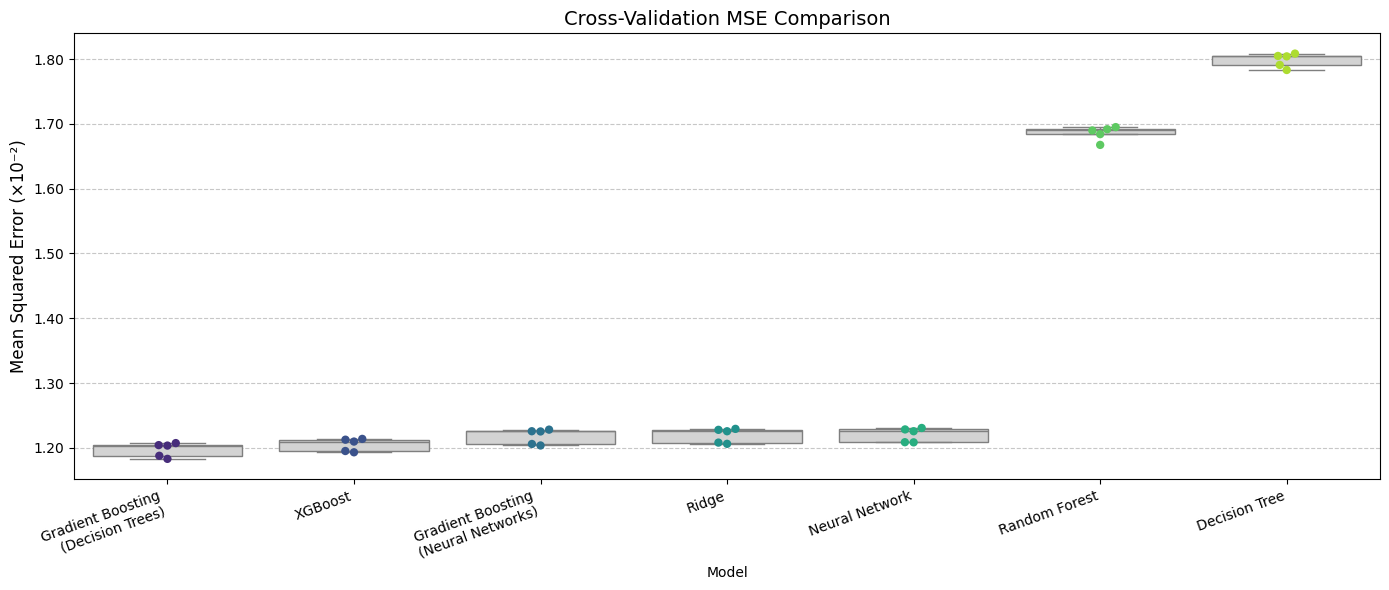

In [19]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Ridge': ridge_mse_scores,
    'Decision Tree': dt_mse_scores,
    'Random Forest': rf_mse_scores,
    'Neural Network': mlp_mse_scores,
    "GB (Decision Trees)": gb_mse_scores,
    'XGBoost': xgb_mse_scores,
    'GB (Neural Networks)': nn_gb_mse_scores
})

melted_df = results_df.melt(var_name='Model', value_name='MSE')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean MSE (best → worst)
model_order = (
    melted_df.groupby('Model')['MSE']
    .mean()
    .sort_values()
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='MSE',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='MSE',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Y-axis in 10^-2 scale
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x*1e2:.2f}'))
plt.ylabel('Mean Squared Error (×10⁻²)', fontsize=12)

# 6. Clean styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation MSE Comparison', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

C:\Users\oriol\AppData\Local\Temp\ipykernel_15076\2374248617.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


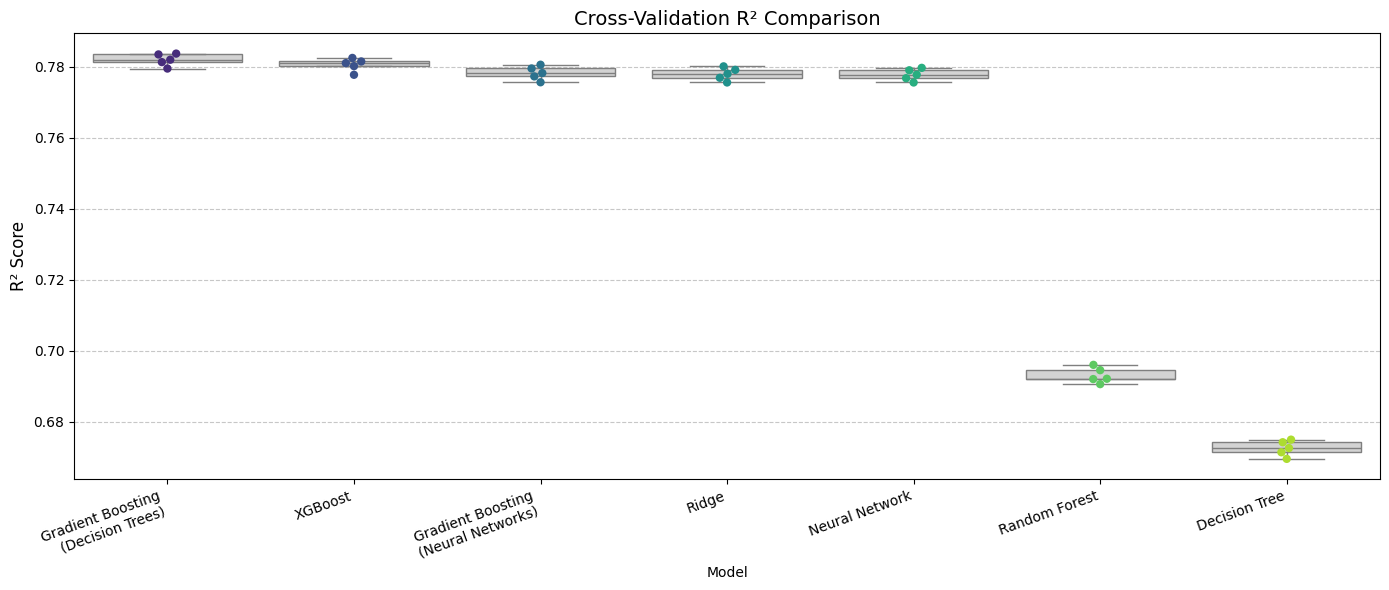

In [20]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Ridge': ridge_r2_scores,
    'Decision Tree': dt_r2_scores,
    'Random Forest': rf_r2_scores,
    'Neural Network': mlp_r2_scores,
    "GB (Decision Trees)": gb_r2_scores,
    'XGBoost': xgb_r2_scores,
    'GB (Neural Networks)': nn_gb_r2_scores
})

melted_df = results_df.melt(var_name='Model', value_name='R2')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean R² (best → worst = descending)
model_order = (
    melted_df.groupby('Model')['R2']
    .mean()
    .sort_values(ascending=False)
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='R2',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='R2',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation R² Comparison', fontsize=14)
plt.ylabel('R² Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### VISUALIZATION (BY MEDIAN)

C:\Users\oriol\AppData\Local\Temp\ipykernel_15076\1612917705.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


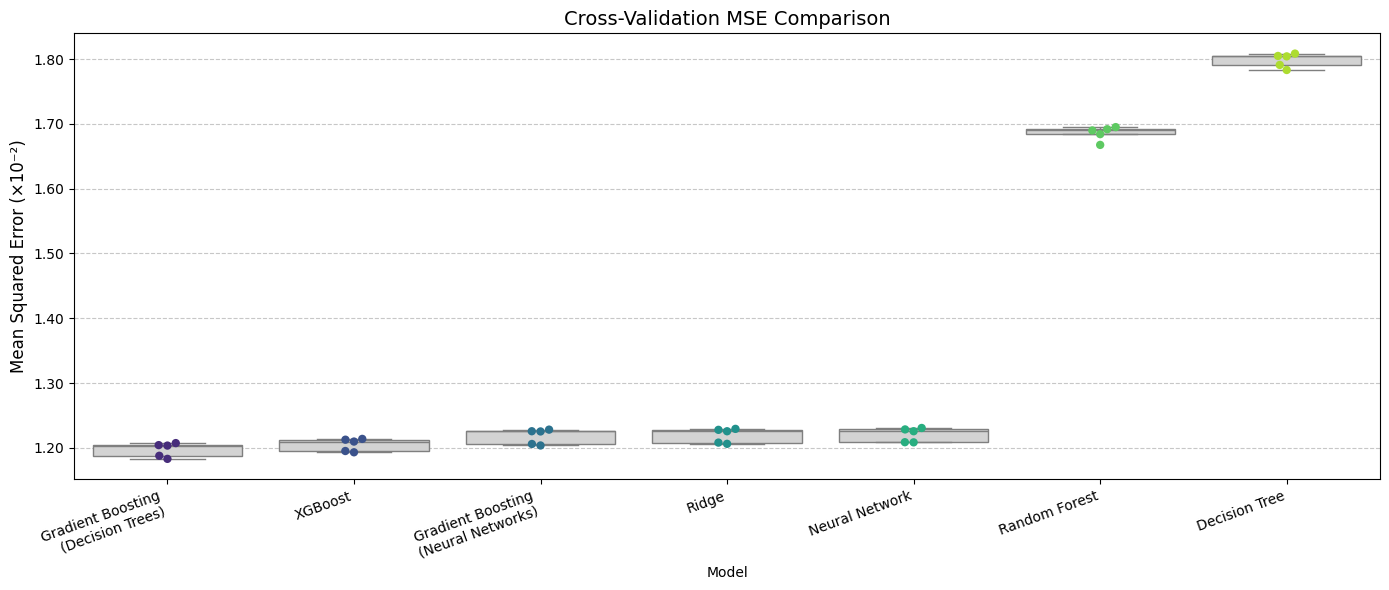

In [21]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Ridge': ridge_mse_scores,
    'Decision Tree': dt_mse_scores,
    'Random Forest': rf_mse_scores,
    'Neural Network': mlp_mse_scores,
    "GB (Decision Trees)": gb_mse_scores,
    'XGBoost': xgb_mse_scores,
    'GB (Neural Networks)': nn_gb_mse_scores
})

melted_df = results_df.melt(var_name='Model', value_name='MSE')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean MSE (best → worst)
model_order = (
    melted_df.groupby('Model')['MSE']
    .median()
    .sort_values()
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='MSE',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='MSE',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Y-axis in 10^-2 scale
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x*1e2:.2f}'))
plt.ylabel('Mean Squared Error (×10⁻²)', fontsize=12)

# 6. Clean styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation MSE Comparison', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

C:\Users\oriol\AppData\Local\Temp\ipykernel_15076\1894387692.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


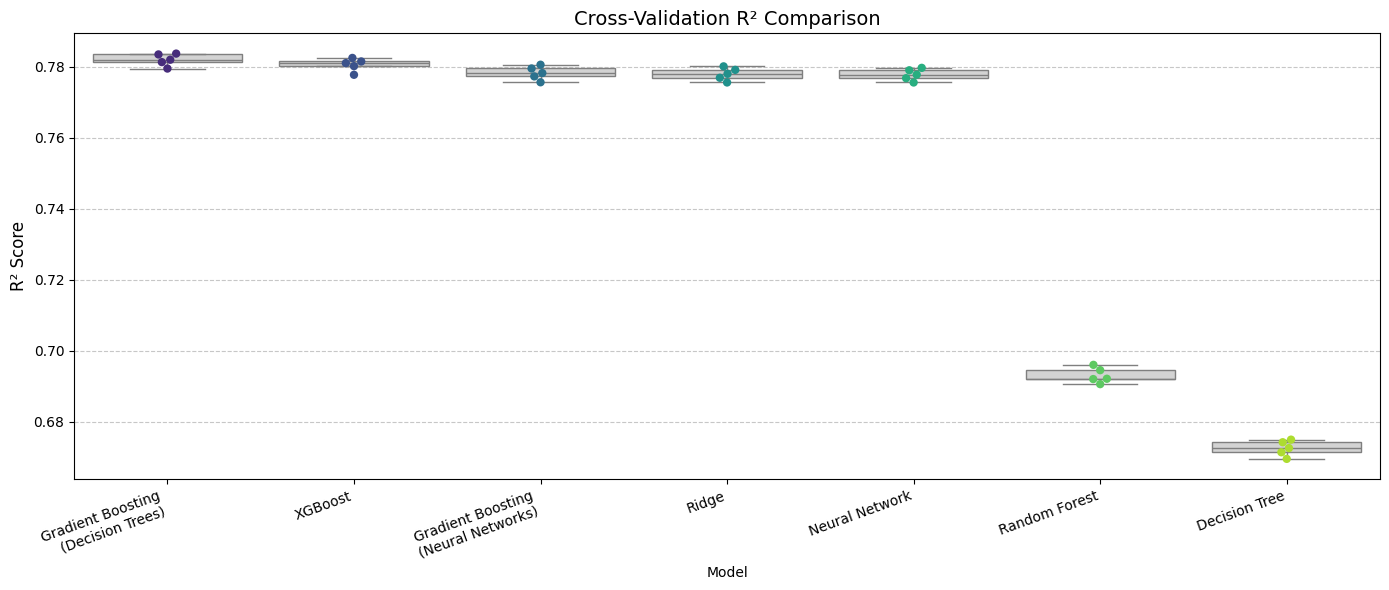

In [26]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Ridge': ridge_r2_scores,
    'Decision Tree': dt_r2_scores,
    'Random Forest': rf_r2_scores,
    'Neural Network': mlp_r2_scores,
    "GB (Decision Trees)": gb_r2_scores,
    'XGBoost': xgb_r2_scores,
    'GB (Neural Networks)': nn_gb_r2_scores
})

melted_df = results_df.melt(var_name='Model', value_name='R2')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean R² (best → worst = descending)
model_order = (
    melted_df.groupby('Model')['R2']
    .median()
    .sort_values(ascending=False)
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='R2',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='R2',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation R² Comparison', fontsize=14)
plt.ylabel('R² Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### VISUALIZATION (WITHOUT DTs AND RFs)

C:\Users\oriol\AppData\Local\Temp\ipykernel_15076\2935190585.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


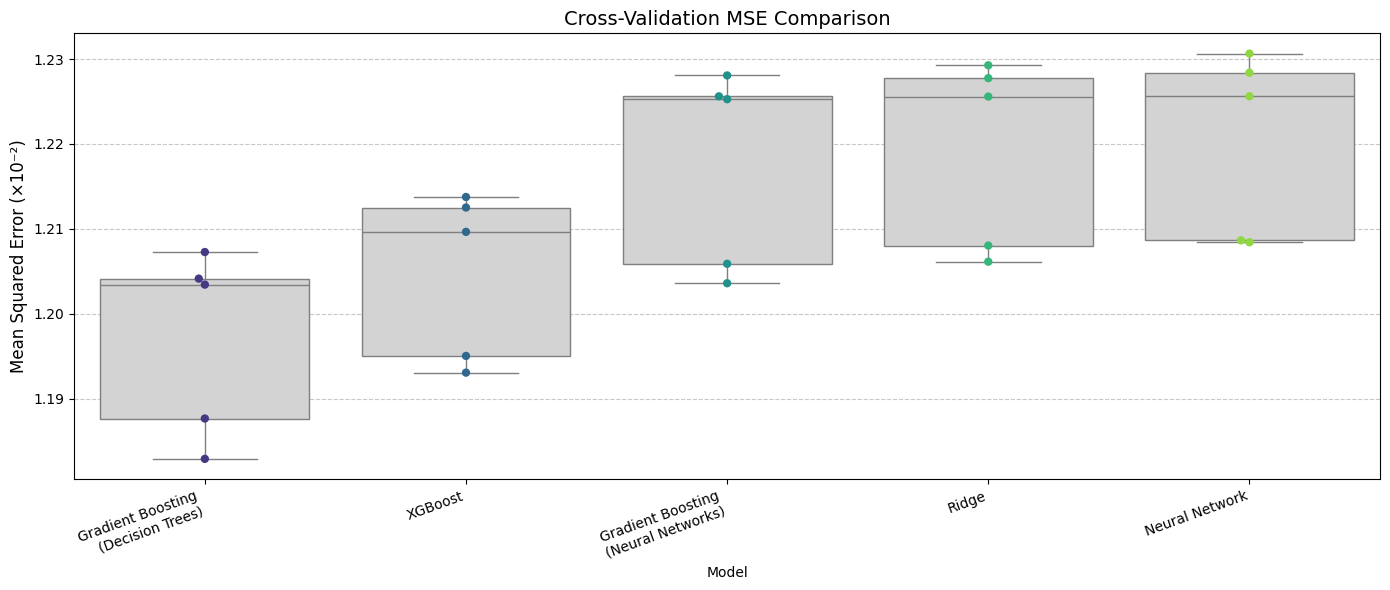

In [23]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Ridge': ridge_mse_scores,
    'Neural Network': mlp_mse_scores,
    "GB (Decision Trees)": gb_mse_scores,
    'XGBoost': xgb_mse_scores,
    'GB (Neural Networks)': nn_gb_mse_scores
})

melted_df = results_df.melt(var_name='Model', value_name='MSE')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean MSE (best → worst)
model_order = (
    melted_df.groupby('Model')['MSE']
    .median()
    .sort_values()
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='MSE',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='MSE',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Y-axis in 10^-2 scale
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x*1e2:.2f}'))
plt.ylabel('Mean Squared Error (×10⁻²)', fontsize=12)

# 6. Clean styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation MSE Comparison', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

C:\Users\oriol\AppData\Local\Temp\ipykernel_15076\3608224838.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


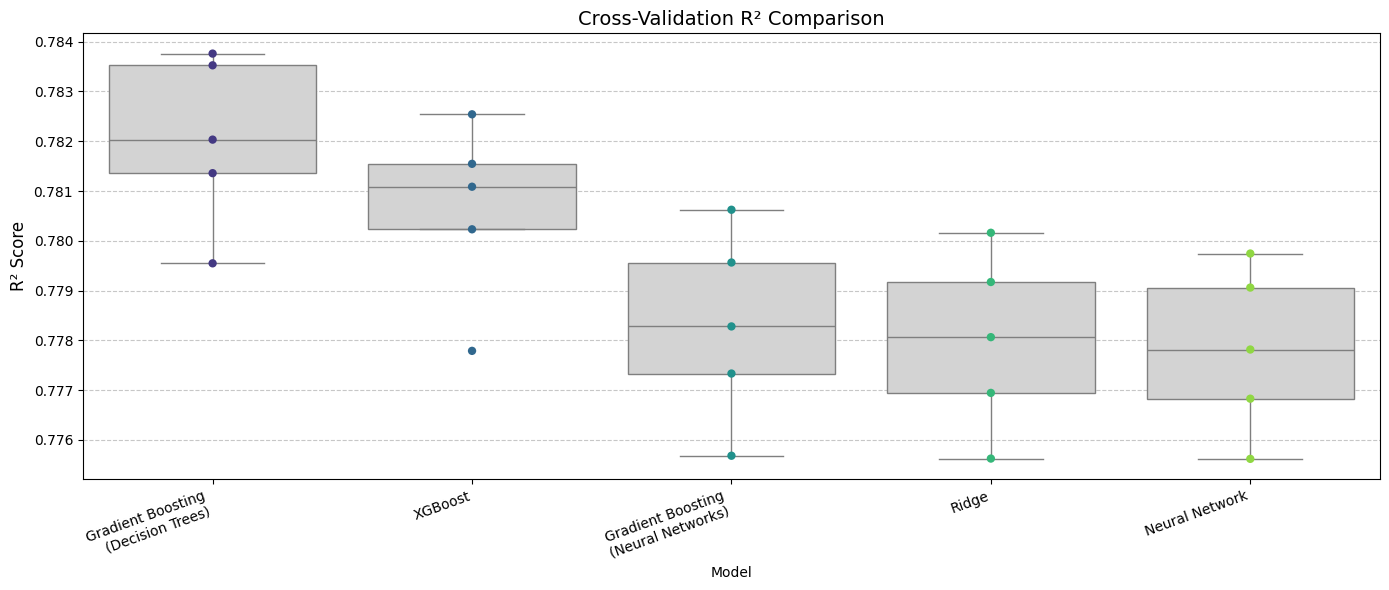

In [25]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Ridge': ridge_r2_scores,
    'Neural Network': mlp_r2_scores,
    "GB (Decision Trees)": gb_r2_scores,
    'XGBoost': xgb_r2_scores,
    'GB (Neural Networks)': nn_gb_r2_scores
})

melted_df = results_df.melt(var_name='Model', value_name='R2')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean R² (best → worst = descending)
model_order = (
    melted_df.groupby('Model')['R2']
    .median()
    .sort_values(ascending=False)
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='R2',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='R2',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation R² Comparison', fontsize=14)
plt.ylabel('R² Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()